In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
import joblib

Initializing the Data & Analyzing the information

In [3]:
df=pd.read_csv("loan_approval_data.csv")

In [4]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

In [6]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


# Handling the missing Values

In [7]:
# here we are sepereating the columns based on the data type by using select_dtypes function to distinguish the column for handling the missing value
categorical_cols=df.select_dtypes(["object"]).columns
numerical_cols=df.select_dtypes(["number"]).columns # here we can also give float64 or int64 or both in the list but number includes all numerical values

Implementing the Imputer for Filling up the missing Value



# Simple Imputer Replace missing values using a descriptive statistic (e.g. mean, median, or most frequent) along each column, or using a constant value 

In [8]:
# Just initalize the Imputer
num_imp=SimpleImputer(strategy="mean")
categor_imp=SimpleImputer(strategy="most_frequent")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])
df[categorical_cols]=categor_imp.fit_transform(df[categorical_cols])

In [9]:
df.isnull().sum()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        1000 non-null   float64
 1   Applicant_Income    1000 non-null   float64
 2   Coapplicant_Income  1000 non-null   float64
 3   Employment_Status   1000 non-null   object 
 4   Age                 1000 non-null   float64
 5   Marital_Status      1000 non-null   object 
 6   Dependents          1000 non-null   float64
 7   Credit_Score        1000 non-null   float64
 8   Existing_Loans      1000 non-null   float64
 9   DTI_Ratio           1000 non-null   float64
 10  Savings             1000 non-null   float64
 11  Collateral_Value    1000 non-null   float64
 12  Loan_Amount         1000 non-null   float64
 13  Loan_Term           1000 non-null   float64
 14  Loan_Purpose        1000 non-null   object 
 15  Property_Area       1000 non-null   object 
 16  Educati

# EDA-Exploratory Data Analaysis

Visulaizing the categories with loan approved or not ?


In [10]:
#how balance ar classses are 
class_loan_approved=df["Loan_Approved"].value_counts()

In [11]:
class_loan_approved

Loan_Approved
No     702
Yes    298
Name: count, dtype: int64

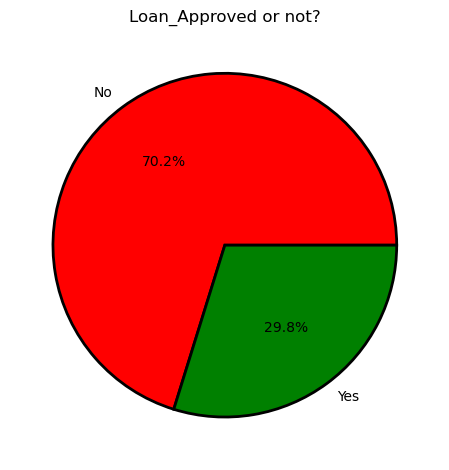

In [12]:
# visulailzing it
plt.pie(class_loan_approved,labels=["No","Yes"],autopct="%1.1f%%",colors=["r","g"], wedgeprops={
        'edgecolor': 'black',
        'linewidth': 2
    })
plt.title("Loan_Approved or not?")
plt.tight_layout()

Visualizing the categories with Gender

In [13]:
class_Gender=df["Gender"].value_counts()

In [14]:
class_Gender

Gender
Male      621
Female    379
Name: count, dtype: int64

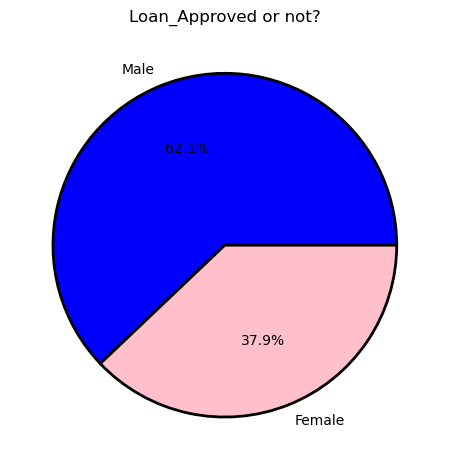

In [15]:
# visulailzing it another categories
plt.pie(class_Gender,labels=["Male","Female"],autopct="%1.1f%%",colors=["b","pink"], wedgeprops={
        'edgecolor': 'black',
        'linewidth': 2
    })
plt.title("Loan_Approved or not?")
plt.tight_layout()

Visualizing the categories with Education level

[Text(0, 0, '722'), Text(0, 0, '278')]

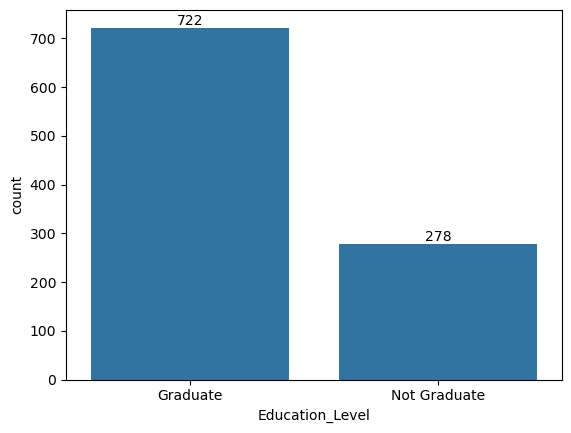

In [16]:
class_EDU=df["Education_Level"].value_counts()
ax=sns.barplot(class_EDU)
ax.bar_label(ax.containers[0])

# Analyze with help of income 

<Axes: xlabel='Applicant_Income', ylabel='Count'>

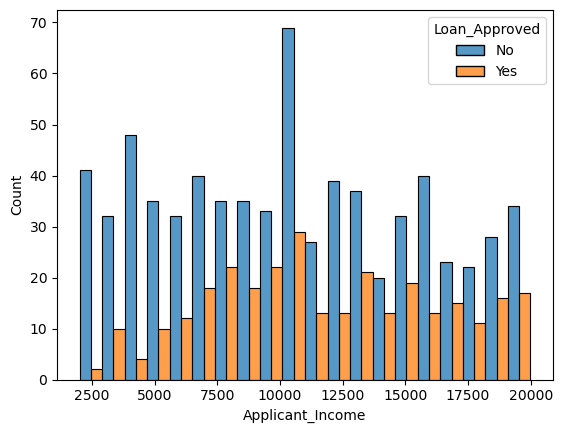

In [17]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    hue="Loan_Approved",
    multiple="dodge",
    bins=20
)

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

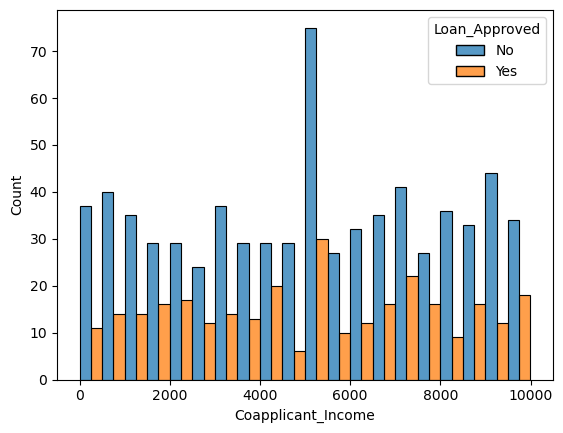

In [18]:
sns.histplot(
    data=df,
    x="Coapplicant_Income",
    hue="Loan_Approved",
    multiple="dodge",
    bins=20
)

For detecting outlier we use box plot

<Axes: xlabel='Loan_Approved', ylabel='Applicant_Income'>

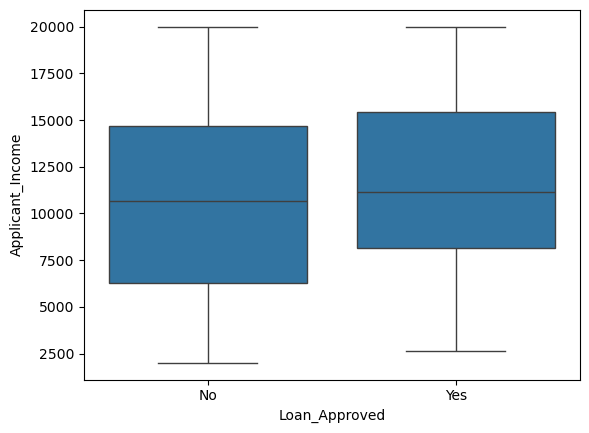

In [19]:
sns.boxplot(
    data=df,
    x='Loan_Approved',
    y='Applicant_Income',
)

no outlier

# Now we are analyzing different categories using box plot 

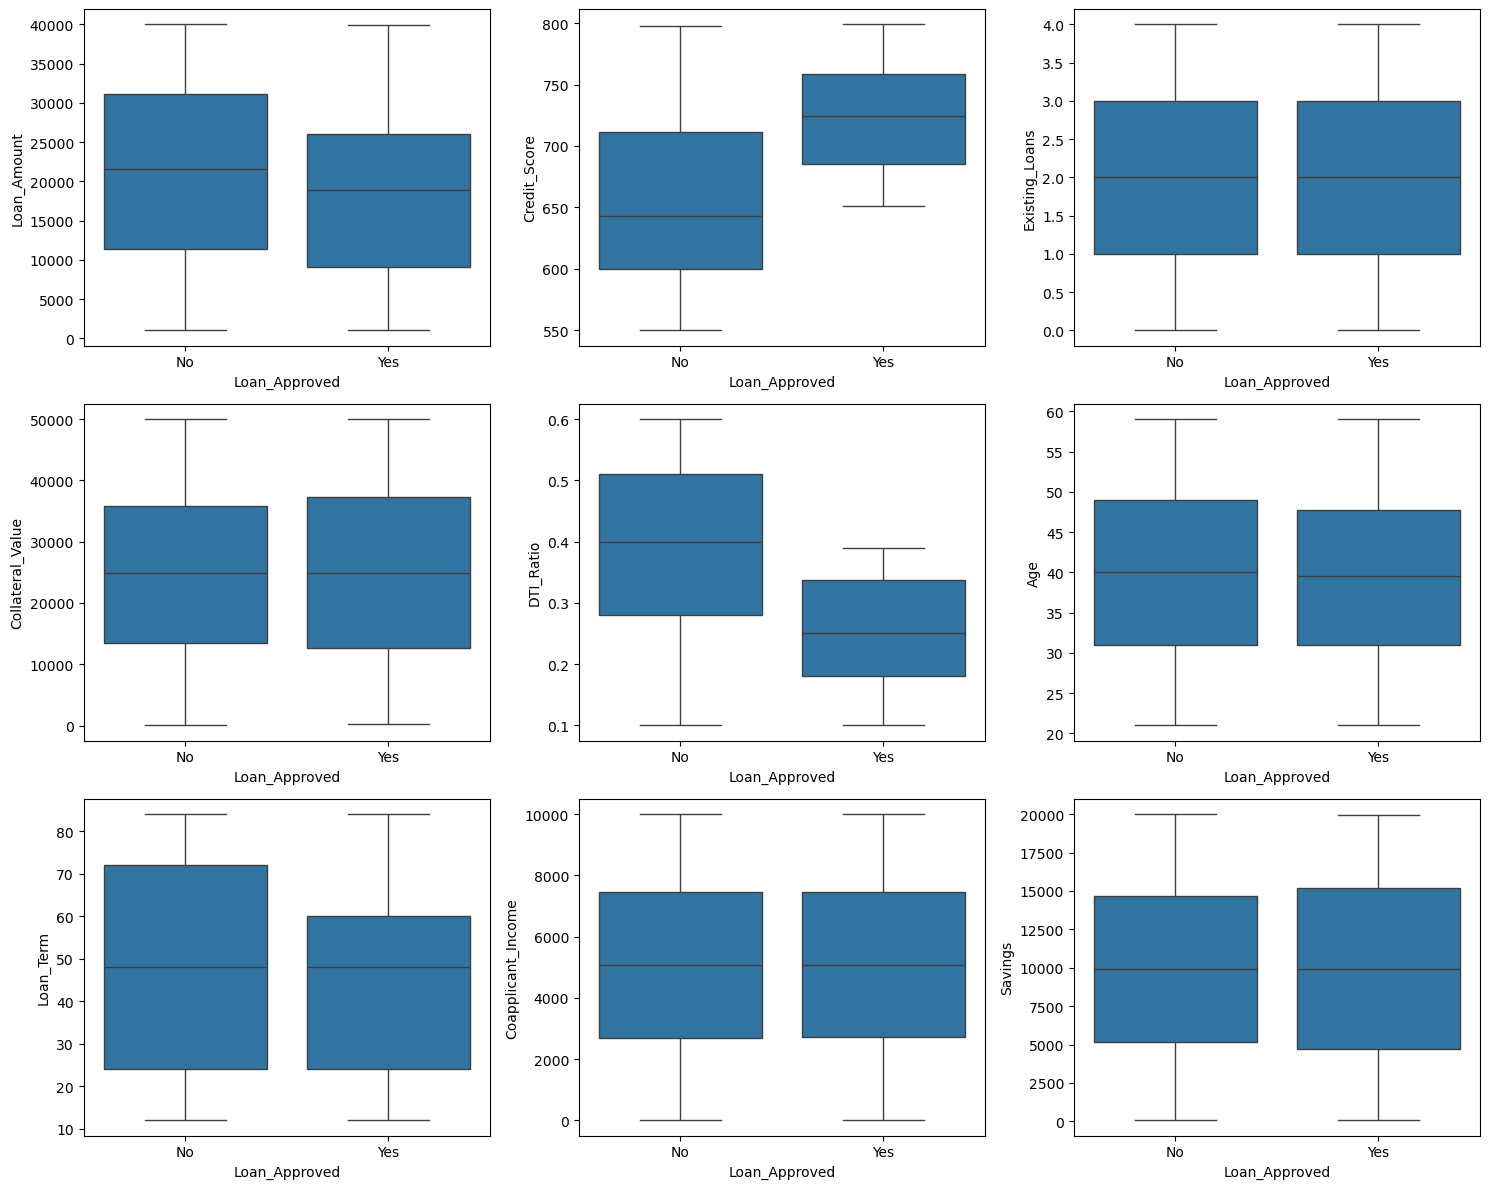

In [20]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

sns.boxplot(ax=axes[0,0], data=df, x='Loan_Approved', y='Loan_Amount')
sns.boxplot(ax=axes[0,1], data=df, x='Loan_Approved', y='Credit_Score')
sns.boxplot(ax=axes[0,2], data=df, x='Loan_Approved', y='Existing_Loans')
sns.boxplot(ax=axes[1,0], data=df, x='Loan_Approved', y='Collateral_Value')
sns.boxplot(ax=axes[1,1], data=df, x='Loan_Approved', y='DTI_Ratio')
sns.boxplot(ax=axes[1,2], data=df, x='Loan_Approved', y='Age')
sns.boxplot(ax=axes[2,0], data=df, x='Loan_Approved', y='Loan_Term')
sns.boxplot(ax=axes[2,1], data=df, x='Loan_Approved', y='Coapplicant_Income')
sns.boxplot(ax=axes[2,2], data=df, x='Loan_Approved', y='Savings')
plt.tight_layout()
# Add other NUMERIC columns here

<Axes: xlabel='Credit_Score', ylabel='Count'>

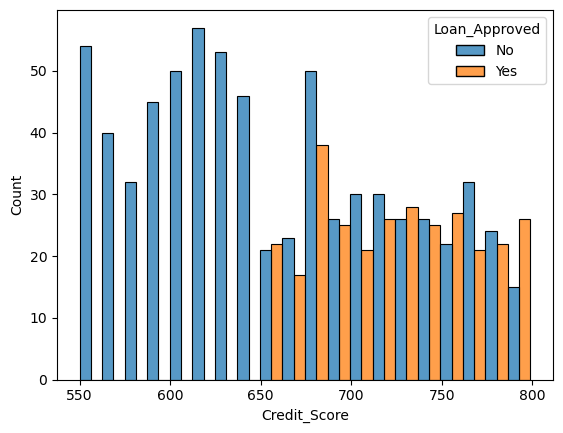

In [21]:
sns.histplot(
    data=df,
    x="Credit_Score",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

In this histogram it is depicting that the Applicant having credit_score Between 650 - 800 there Loan_Applicantion are Getting Approved.


In [22]:
df=df.drop("Applicant_ID", axis=1) 

We Just removed Applicant_Id because it is not going to effect any changes to our model as the Applicant_ID is assign by the bank to the Applicant

In [23]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    1000 non-null   float64
 1   Coapplicant_Income  1000 non-null   float64
 2   Employment_Status   1000 non-null   object 
 3   Age                 1000 non-null   float64
 4   Marital_Status      1000 non-null   object 
 5   Dependents          1000 non-null   float64
 6   Credit_Score        1000 non-null   float64
 7   Existing_Loans      1000 non-null   float64
 8   DTI_Ratio           1000 non-null   float64
 9   Savings             1000 non-null   float64
 10  Collateral_Value    1000 non-null   float64
 11  Loan_Amount         1000 non-null   float64
 12  Loan_Term           1000 non-null   float64
 13  Loan_Purpose        1000 non-null   object 
 14  Property_Area       1000 non-null   object 
 15  Education_Level     1000 non-null   object 
 16  Gender 

# Encoding

Label Encoder for level based categorical values and gives output of single column

In [25]:
# now we are doing the encoding process for the all object features and by using onehotencoding and labelencoding for the single out put we are doing 
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])
       

OneHotEncoding for multiple categorical encoding and gives multiple output columns and used drop first for countering multi-collinearity
                                                                                                       

In [26]:
cols=["Gender","Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Employer_Category"]
ohe=OneHotEncoder(sparse_output=False,drop="first",handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])


Since OneHotEncoder gives output in array we have to convert it in to data frame then we will concatenate with original data frame

So we need to know the all columns name consist in OneHotEncoder

In [27]:
ohe.get_feature_names_out(cols)

array(['Gender_Male', 'Employment_Status_Salaried',
       'Employment_Status_Self-employed', 'Employment_Status_Unemployed',
       'Marital_Status_Single', 'Loan_Purpose_Car',
       'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed'], dtype=object)

In [28]:
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)
# now we are concatinating the original df and encoded_df for including encoded columns and deleting old columns from original ,
# as the are no more valid or useful for the model training purpose 
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [29]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


# Corelation Heatmap

It is a visual representation of the relationships between numerical variables in a data.
It shows Correlation coefficient (r) between two numeric variables,
ranges from -1 to 1.
1 is perfect positive correlation.
-1 is perfect negative correlation.
O is no linear correlation.

In [30]:
nums_cols=df.select_dtypes(include="number")
corr_matrix=nums_cols.corr()

In [31]:
corr_matrix

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
Applicant_Income,1.000000,0.007545,-0.023988,-0.026658,-0.009818,-0.010457,-0.009107,-0.028358,0.018789,-0.024143,...,-0.083398,0.032794,0.074209,-0.031234,0.004845,-0.036260,-0.025011,0.102589,-0.044639,-0.011995
Coapplicant_Income,0.007545,1.000000,0.014306,-0.026733,0.058423,0.012418,0.058078,-0.015047,0.009457,0.001596,...,-0.020148,0.028000,0.016022,0.059549,-0.010058,0.030045,-0.001146,0.037640,0.004312,-0.047929
Age,-0.023988,0.014306,1.000000,-0.018767,-0.004212,0.023330,0.007903,-0.000986,0.037382,0.013502,...,-0.025521,-0.006283,0.029865,0.037293,0.003100,-0.025661,-0.066041,0.021232,-0.012960,0.072462
Dependents,-0.026658,-0.026733,-0.018767,1.000000,-0.007687,-0.026338,0.011498,-0.004981,0.023004,-0.017409,...,-0.043685,-0.044642,0.027343,-0.005785,-0.032278,0.024082,-0.009250,-0.018757,0.030197,-0.054147
Credit_Score,-0.009818,0.058423,-0.004212,-0.007687,1.000000,-0.007130,0.002338,-0.065353,0.007865,0.001002,...,-0.030142,0.026013,-0.008658,0.015324,-0.006946,0.004445,-0.007076,0.066736,-0.000049,-0.046087
Existing_Loans,-0.010457,0.012418,0.023330,-0.026338,-0.007130,1.000000,0.047008,0.034435,-0.049916,-0.021035,...,-0.025228,-0.010035,0.001777,0.023212,-0.053971,0.035629,-0.009642,0.030520,-0.019306,0.045391
DTI_Ratio,-0.009107,0.058078,0.007903,0.011498,0.002338,0.047008,1.000000,0.004663,-0.009622,0.075784,...,-0.020907,0.040432,-0.014125,-0.036648,0.044898,-0.006156,-0.007214,0.002090,-0.003506,0.026018
Savings,-0.028358,-0.015047,-0.000986,-0.004981,-0.065353,0.034435,0.004663,1.000000,0.015481,-0.012208,...,-0.009133,0.032558,-0.012217,-0.028948,0.005438,0.016833,-0.011683,0.004381,-0.030208,0.027178
Collateral_Value,0.018789,0.009457,0.037382,0.023004,0.007865,-0.049916,-0.009622,0.015481,1.000000,0.002660,...,0.031112,0.040406,-0.050975,-0.007120,0.020061,0.007975,0.035760,-0.013464,-0.014480,-0.009655
Loan_Amount,-0.024143,0.001596,0.013502,-0.017409,0.001002,-0.021035,0.075784,-0.012208,0.002660,1.000000,...,-0.006788,-0.006119,-0.000930,0.032498,0.040206,-0.050076,0.013108,-0.025975,0.013923,-0.026566


So in this we are getting the all corelation between each column to each other , now we want to 
find correaltion of all column with out target column ["Loan Approved "]

In [32]:
Corr_Matrix_Loan=pd.DataFrame(nums_cols.corr()["Loan_Approved"].sort_values(ascending=False))

In [33]:
Corr_Matrix_Loan

,Loan_Approved
Loan_Approved,1.000000
Credit_Score,0.451175
Applicant_Income,0.119796
Employer_Category_MNC,0.069049
Loan_Purpose_Personal,0.034043
Marital_Status_Single,0.030182
Property_Area_Urban,0.025963
Collateral_Value,0.021868
Coapplicant_Income,0.004230
Loan_Purpose_Home,0.002118


So in this dataframe it denote that Credit_score and Income has more impact on the target value of Loan Approved which will change the output

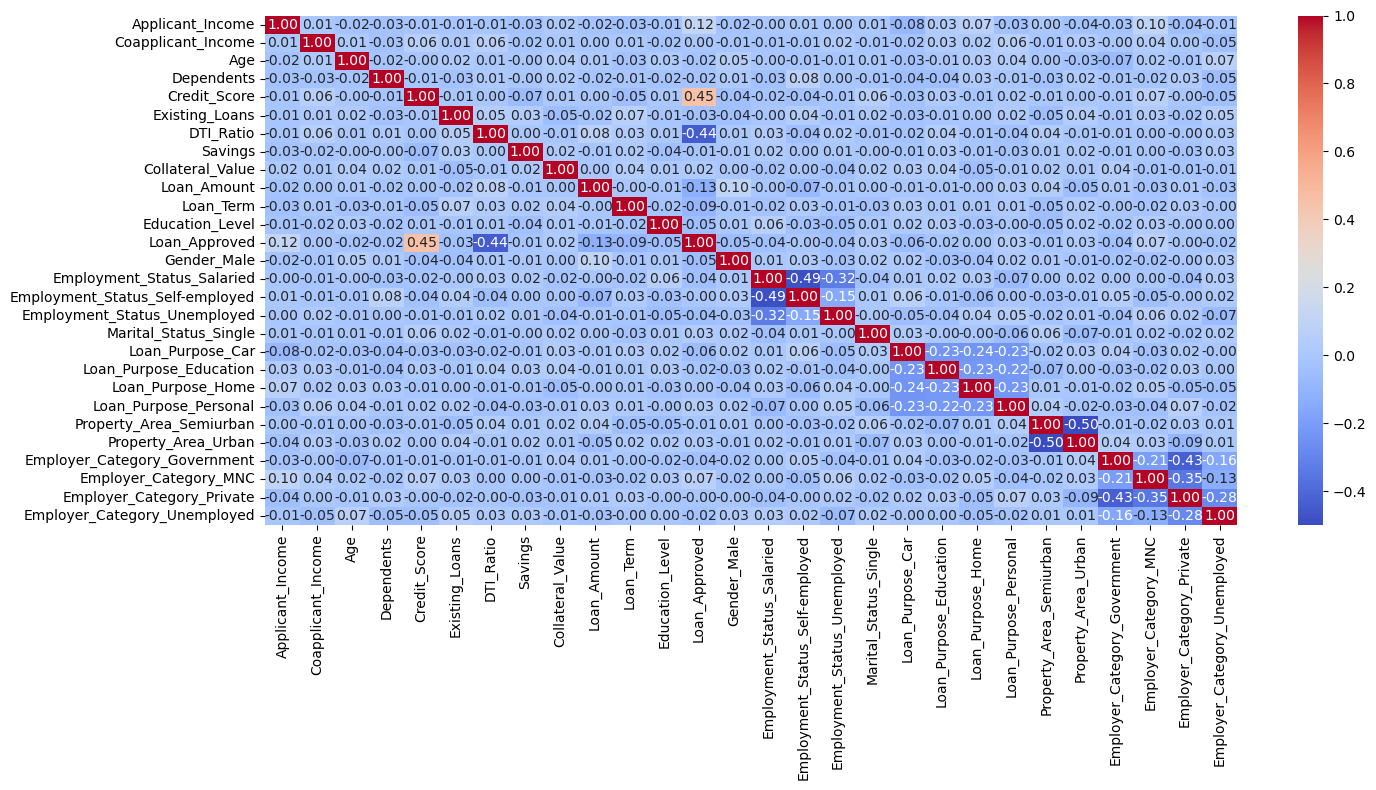

In [34]:
# Now we are ploting the heatmap of Correaltion of all the columns 
plt.figure(figsize=(15,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.tight_layout()

# Train_Test_Split & Feature_Scaling

In [35]:
X=df.drop("Loan_Approved",axis=1)
Y=df["Loan_Approved"]

In [36]:
X.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Car,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


In [37]:
Y.head()

0    0
1    0
2    1
3    0
4    1
Name: Loan_Approved, dtype: int64

In [38]:
X_train ,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=42,test_size=0.2)

In [39]:
# Now we are scaling the data to avoid machine learning for equally treating the features of data
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Trainning and evaluated the model

LogisticRegression

In [40]:
log_model=LogisticRegression()
log_model.fit(X_train_scaled,Y_train)
Y_pred=log_model.predict(X_test_scaled)
# Evalution
print("Evalution for Logistic_Regression")
print(f"The precision score : {precision_score(Y_test,Y_pred)*100}%")
print(f"The accuracy_score  : {accuracy_score(Y_test,Y_pred)*100}%")
print(f"The confusion_matrix: {confusion_matrix(Y_test,Y_pred)}")
print(f"The f1_score        : {f1_score(Y_test,Y_pred)*100}%")
print(f"The recall_score    : {recall_score(Y_test,Y_pred)*100}%")

Evalution for Logistic_Regression
The precision score : 78.33333333333333%
The accuracy_score  : 86.5%
The confusion_matrix: [[126  13]
 [ 14  47]]
The f1_score        : 77.68595041322314%
The recall_score    : 77.04918032786885%


KNN Classifer

In [41]:
Knn_model=KNeighborsClassifier(n_neighbors=13)
Knn_model.fit(X_train_scaled,Y_train)
Y_k_pred=Knn_model.predict(X_test_scaled)
# Evalution
print("Evalution for Logistic_Regression")
print(f"The precision score : {precision_score(Y_test,Y_k_pred)*100}%")
print(f"The accuracy_score  : {accuracy_score(Y_test,Y_k_pred)*100}%")
print(f"The confusion_matrix: {confusion_matrix(Y_test,Y_k_pred)}")
print(f"The f1_score        : {f1_score(Y_test,Y_k_pred)*100}%")
print(f"The recall_score    : {recall_score(Y_test,Y_k_pred)*100}%")
# Here after increasing n_neighbors value precision is imporving gradually but recall is gettting worse

Evalution for Logistic_Regression
The precision score : 73.17073170731707%
The accuracy_score  : 79.0%
The confusion_matrix: [[128  11]
 [ 31  30]]
The f1_score        : 58.82352941176471%
The recall_score    : 49.18032786885246%


Naive_Bayes

In [42]:
nb_model=GaussianNB()
nb_model.fit(X_train_scaled,Y_train)
Y_n_pred=nb_model.predict(X_test_scaled)
# Evalution
print("Evalution for Logistic_Regression")
print(f"The precision score : {precision_score(Y_test,Y_n_pred)*100}%")
print(f"The accuracy_score  : {accuracy_score(Y_test,Y_n_pred)*100}%")
print(f"The confusion_matrix: {confusion_matrix(Y_test,Y_n_pred)}")
print(f"The f1_score        : {f1_score(Y_test,Y_n_pred)*100}%")
print(f"The recall_score    : {recall_score(Y_test,Y_n_pred)*100}%")

Evalution for Logistic_Regression
The precision score : 80.35714285714286%
The accuracy_score  : 86.5%
The confusion_matrix: [[128  11]
 [ 16  45]]
The f1_score        : 76.92307692307693%
The recall_score    : 73.77049180327869%


## so the best model for the precision score is naive baiyes

# Feature_Engineering 

### A dataset is skewed when its values are not evenly distributed around the center.

In [44]:
# now we are squaring the features like DTI and Credit_Score 
df["DTI_Ratio_q"]=df["DTI_Ratio"]**2
df["Credit_Score_q"]=df["Credit_Score"]**2

#Transforming the Income data because it is right skewed or right side biased
df["Applicant_Income_log"]=np.log1p(df["Applicant_Income"])
df["Co_Applicant_Income_log"]=np.log1p(df["Coapplicant_Income"])
X=df.drop(columns=["Loan_Approved","Applicant_Income","Credit_Score","DTI_Ratio","Coapplicant_Income"])
Y=df["Loan_Approved"]



In [60]:
X.columns

Index(['Age', 'Dependents', 'Existing_Loans', 'Savings', 'Collateral_Value',
       'Loan_Amount', 'Loan_Term', 'Education_Level', 'Gender_Male',
       'Employment_Status_Salaried', 'Employment_Status_Self-employed',
       'Employment_Status_Unemployed', 'Marital_Status_Single',
       'Loan_Purpose_Car', 'Loan_Purpose_Education', 'Loan_Purpose_Home',
       'Loan_Purpose_Personal', 'Property_Area_Semiurban',
       'Property_Area_Urban', 'Employer_Category_Government',
       'Employer_Category_MNC', 'Employer_Category_Private',
       'Employer_Category_Unemployed', 'DTI_Ratio_q', 'Credit_Score_q',
       'Applicant_Income_log', 'Co_Applicant_Income_log'],
      dtype='object')

In [46]:
##doing Train test split
X_train ,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=42,test_size=0.2)
Y_train.head()

29     0
535    0
695    0
557    0
836    1
Name: Loan_Approved, dtype: int64

In [47]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [48]:
log_model=LogisticRegression()
log_model.fit(X_train_scaled,Y_train)
Y_pred=log_model.predict(X_test_scaled)
# Evalution
print("Evalution for Logistic_Regression")
print(f"The precision score : {precision_score(Y_test,Y_pred)*100}%")
print(f"The accuracy_score  : {accuracy_score(Y_test,Y_pred)*100}%")
print(f"The confusion_matrix: {confusion_matrix(Y_test,Y_pred)}")
print(f"The f1_score        : {f1_score(Y_test,Y_pred)*100}%")
print(f"The recall_score    : {recall_score(Y_test,Y_pred)*100}%")

Evalution for Logistic_Regression
The precision score : 77.77777777777779%
The accuracy_score  : 87.0%
The confusion_matrix: [[125  14]
 [ 12  49]]
The f1_score        : 79.03225806451613%
The recall_score    : 80.32786885245902%


In [49]:
Knn_model=KNeighborsClassifier(n_neighbors=13)
Knn_model.fit(X_train_scaled,Y_train)
Y_k_pred=Knn_model.predict(X_test_scaled)
# Evalution
print("Evalution for Logistic_Regression")
print(f"The precision score : {precision_score(Y_test,Y_k_pred)*100}%")
print(f"The accuracy_score  : {accuracy_score(Y_test,Y_k_pred)*100}%")
print(f"The confusion_matrix: {confusion_matrix(Y_test,Y_k_pred)}")
print(f"The f1_score        : {f1_score(Y_test,Y_k_pred)*100}%")
print(f"The recall_score    : {recall_score(Y_test,Y_k_pred)*100}%")
# Here after increasing n_neighbors value precision is imporving gradually but recall is gettting worse

Evalution for Logistic_Regression
The precision score : 76.92307692307693%
The accuracy_score  : 80.0%
The confusion_matrix: [[130   9]
 [ 31  30]]
The f1_score        : 60.0%
The recall_score    : 49.18032786885246%


In [50]:
nb_model=GaussianNB()
nb_model.fit(X_train_scaled,Y_train)
Y_n_pred=nb_model.predict(X_test_scaled)
# Evalution
print("Evalution for Logistic_Regression")
print(f"The precision score : {precision_score(Y_test,Y_n_pred)*100}%")
print(f"The accuracy_score  : {accuracy_score(Y_test,Y_n_pred)*100}%")
print(f"The confusion_matrix: {confusion_matrix(Y_test,Y_n_pred)}")
print(f"The f1_score        : {f1_score(Y_test,Y_n_pred)*100}%")
print(f"The recall_score    : {recall_score(Y_test,Y_n_pred)*100}%")

Evalution for Logistic_Regression
The precision score : 80.35714285714286%
The accuracy_score  : 86.5%
The confusion_matrix: [[128  11]
 [ 16  45]]
The f1_score        : 76.92307692307693%
The recall_score    : 73.77049180327869%


In [52]:

joblib.dump(ohe,"onehot_encoder.pkl")

['onehot_encoder.pkl']

In [56]:

joblib.dump(le,"label_encoder.pkl")

['label_encoder.pkl']

In [57]:

joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [55]:
joblib.dump(nb_model,"loan_model.pkl")

['loan_model.pkl']